# 1. Carga de datos

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

with open("../../data/experiment_analysis.json") as f:
    data = json.load(f)

topics = data["topics"]

df = pd.DataFrame.from_dict(topics, orient="index")
df.reset_index(inplace=True)
df.rename(columns={"index": "topic"}, inplace=True)

# 2. Caracterización del tráfico

## 2.1. Ancho de banda

In [3]:
df["bw_percent"] = df["bandwidth_mb_s"] / df["bandwidth_mb_s"].sum() * 100
df.sort_values(by="bw_percent", ascending=False)[["topic", "bandwidth_mb_s", "bw_percent"]].head(10)

,topic,bandwidth_mb_s,bw_percent
36,/robot/front_rgbd_camera/depth/points,71.088803,70.868156
40,/robot/front_rgbd_camera/depth/image_raw,8.886586,8.859003
50,/robot/front_rgbd_camera/rgb/image_raw,6.665086,6.644399
77,/robot/robot_front_ptz_camera/image_raw,6.665071,6.644384
28,/robot/move_base/GlobalPlanner/potential,3.094075,3.084471
64,/gazebo/link_states,1.972124,1.966003
69,/gazebo/model_states,1.099804,1.096390
37,/robot/front_laser/scan,0.331207,0.330179
60,/robot/move_base/global_costmap/costmap_updates,0.069513,0.069297
1,/robot/map,0.068757,0.068544


In [4]:
df_sorted = df.sort_values(by="bw_percent", ascending=False)
df_sorted["cum"] = df_sorted["bw_percent"].cumsum()
n_topics = len(df_sorted)
top_95 = df_sorted[df_sorted["cum"] <= 95]

print("Top topics:", len(top_95))
print("Percentage:", len(top_95) / n_topics * 100)

Top topics: 4
Percentage: 4.761904761904762


## 2.2. Frecuencia

In [5]:
df.sort_values(by="frequency_hz", ascending=False)[["topic", "frequency_hz"]].head(10)

,topic,frequency_hz
70,/clock,997.216015
64,/gazebo/link_states,997.069490
69,/gazebo/model_states,996.739807
8,/tf,136.928093
58,/robot/joint_states,100.131873
75,/robot/joint_pan_position_controller/state,100.021979
26,/robot/joint_tilt_position_controller/state,99.820506
78,/robot/imu/data_raw,98.684934
15,/robot/imu/rpy/filtered,98.684934
7,/robot/imu/data,98.684934


## 2.3. Tamaño

In [6]:
df.sort_values(by="avg_size_kb", ascending=False)[["topic","avg_size_kb"]].head(10)

,topic,avg_size_kb
36,/robot/front_rgbd_camera/depth/points,9600.139648
1,/robot/map,3844.102539
28,/robot/move_base/GlobalPlanner/potential,3844.102539
66,/robot/move_base/global_costmap/costmap,3844.102539
40,/robot/front_rgbd_camera/depth/image_raw,1200.083008
50,/robot/front_rgbd_camera/rgb/image_raw,900.082031
77,/robot/robot_front_ptz_camera/image_raw,900.080078
60,/robot/move_base/global_costmap/costmap_updates,82.687500
45,/robot/move_base/local_costmap/costmap,39.166016
63,/robot/particlecloud,31.696289


## 2.4. Distribución global

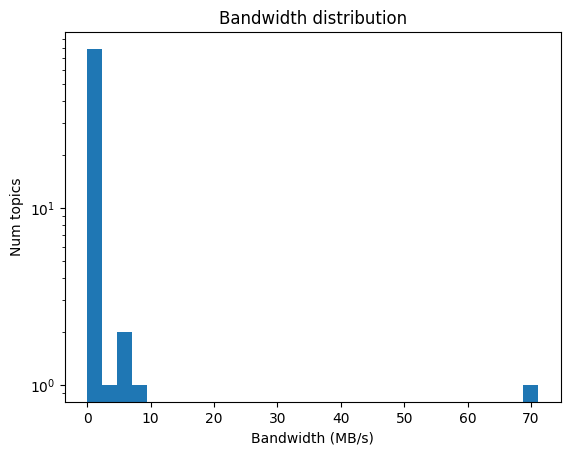

In [7]:
plt.hist(df["bandwidth_mb_s"], bins=30)
plt.xlabel("Bandwidth (MB/s)")
plt.ylabel("Num topics")
plt.title("Bandwidth distribution")
plt.yscale("log")
plt.show()

## 2.5. Relación frecuencia vs tamaño

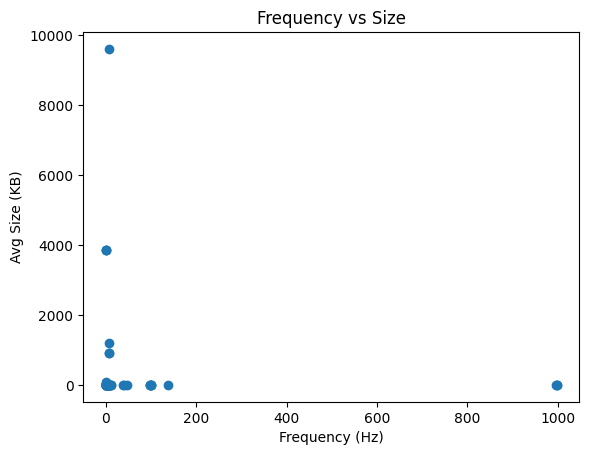

In [8]:
plt.scatter(df["frequency_hz"], df["avg_size_kb"])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Avg Size (KB)")
plt.title("Frequency vs Size")
plt.show()

## 2.6. Relación frecuencia vs bandwidth

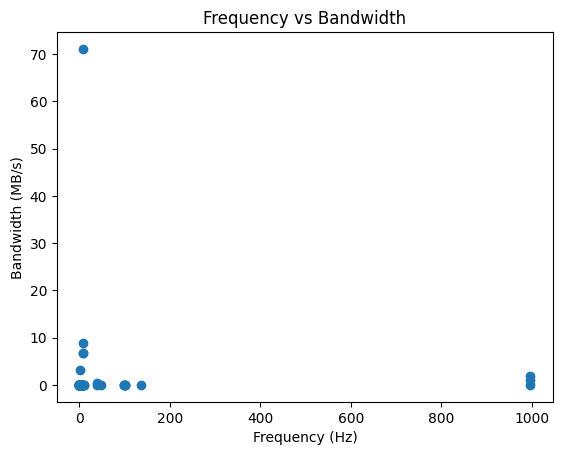

In [9]:
plt.scatter(df["frequency_hz"], df["bandwidth_mb_s"])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Bandwidth (MB/s)")
plt.title("Frequency vs Bandwidth")
plt.show()

## 2.7. Validación BW ≈ frecuencia × tamaño


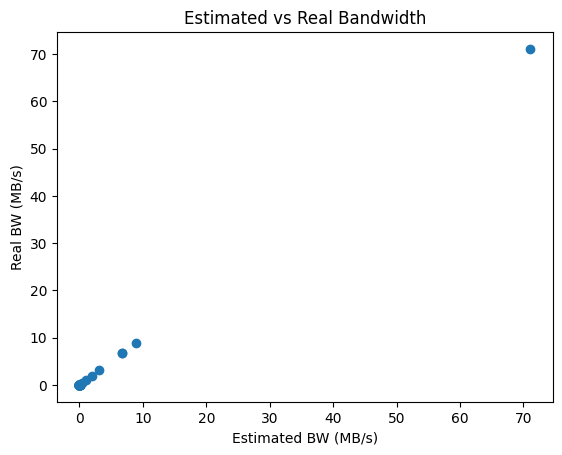

In [10]:
df["bw_estimated"] = df["frequency_hz"] * df["avg_size_kb"] / 1024

plt.scatter(df["bw_estimated"], df["bandwidth_mb_s"])
plt.xlabel("Estimated BW (MB/s)")
plt.ylabel("Real BW (MB/s)")
plt.title("Estimated vs Real Bandwidth")
plt.show()

In [11]:
from sklearn.metrics import r2_score

r2 = r2_score(df["bandwidth_mb_s"], df["bw_estimated"])
print("R2:", r2)

R2: 0.9999999999983807


## 2.8. Conclusiones


El tráfico del sistema presenta una distribución fuertemente concentrada, donde un subconjunto reducido de *topics* acumula la mayor parte del ancho de banda total. Empíricamente, aproximadamente el 95% del tráfico se concentra en torno al X% de los *topics*, confirmando un comportamiento tipo long-tail.

El análisis muestra que el ancho de banda está principalmente determinado por el tamaño de los mensajes y no por la frecuencia de publicación. Esto se valida mediante la fuerte correlación entre el ancho de banda real y el estimado (BW ≈ frecuencia × tamaño), con un coeficiente R² = X.

Los *topics* dominantes corresponden a sensores de percepción (cámaras RGB-D y *point clouds*), lo que indica que el sistema está fuertemente condicionado por la carga de datos sensoriales.

En contraste, la mayoría de los *topics* tienen un impacto marginal en el tráfico global.

# 3. Selección de flujo crítico

## 3.1. Filtrado de flujo crítico

In [12]:
BW_THRESHOLD = df["bandwidth_mb_s"].quantile(0.9)

critical_topics = df[df["bandwidth_mb_s"] > BW_THRESHOLD].copy().sort_values(by="bandwidth_mb_s", ascending=False)

## 3.2. Conclusiones

La selección basada en percentil (p90) permite aislar los *topics* que dominan el consumo de red. Estos *topics* representan los principales candidatos para optimización, ya que pequeñas mejoras en ellos tienen un impacto significativo en el sistema global.

Este filtrado reduce el espacio de análisis sin pérdida relevante de información, centrando el estudio en los flujos realmente críticos.

# 4. Analisis estructural

## 4.1 Carga grafo

In [13]:
with open("../../data/node_topic_graph.json") as f:
    graph = json.load(f)

## 4.2. Dependencias

In [14]:
rows = []

for _, row in critical_topics.iterrows():
    topic = row["topic"]
    pubs = graph.get(topic, {}).get("publishers", [])
    subs = graph.get(topic, {}).get("subscribers", [])

    rows.append({
        "topic": topic,
        "bw": row["bandwidth_mb_s"],
        "publishers": pubs,
        "subscribers": subs,
        "n_pub": len(pubs),
        "n_sub": len(subs)
    })

df_dep = pd.DataFrame(rows).sort_values(by="bw", ascending=False)

In [15]:
df_dep[df_dep["n_sub"] == 0]

,topic,bw,publishers,subscribers,n_pub,n_sub


## 4.3. Clasificación funcional

In [16]:
def classify_node(node):
    if any(k in node for k in ["camera", "laser", "points", "image", "depth"]):
        return "perception"
    elif "move_base" in node:
        return "planning"
    elif "amcl" in node:
        return "localization"
    elif "costmap" in node:
        return "mapping"
    elif "cmd_vel" in node:
        return "control"
    else:
        return "system"

df_dep["pub_type"] = df_dep["publishers"].apply(lambda x: [classify_node(n) for n in x])
df_dep["sub_type"] = df_dep["subscribers"].apply(lambda x: [classify_node(n) for n in x])

## 4.4.Clasificación funcional agragada

In [17]:
from collections import Counter

def dominant_type(types):
    if not types:
        return "unknown"
    return Counter(types).most_common(1)[0][0]

df_dep["main_type"] = df_dep["pub_type"].apply(dominant_type)
df_dep.groupby("main_type")["bw"].sum().sort_values(ascending=False)

main_type
system      96.708680
planning     3.163588
Name: bw, dtype: float64

## 4.5. Conclusiones

El análisis estructural revela que los *topics* de mayor ancho de banda suelen presentar un alto número de suscriptores, amplificando su impacto en la red.

La clasificación funcional muestra que la carga del sistema está dominada por componentes de percepción, mientras que los módulos de planificación y control tienen un impacto significativamente menor en términos de tráfico.

Esto sugiere que el sistema sigue una arquitectura típica de robótica: alta generación de datos en sensores y consumo distribuido en múltiples módulos.

# 5. Dinámica temporal

## 5.1. Métricas

In [18]:
df_dep["lat_mean_ms"] = df_dep["topic"].apply(lambda t: topics[t].get("lat_mean_ms", 0))
df_dep["jitter_ms"] = df_dep["topic"].apply(lambda t: topics[t].get("jitter_ms", 0))
df_dep["peak_bw"] = df_dep["topic"].apply(lambda t: topics[t].get("peak_bandwidth_mb_s", 0))

In [19]:
df_dep.sort_values(
    by=["lat_mean_ms","bw"],
    ascending=[False, False]
)[["topic","bw","lat_mean_ms"]].head(10)

,topic,bw,lat_mean_ms
3,/robot/robot_front_ptz_camera/image_raw,6.665071,131.855072
2,/robot/front_rgbd_camera/rgb/image_raw,6.665086,108.101449
1,/robot/front_rgbd_camera/depth/image_raw,8.886586,107.681159
0,/robot/front_rgbd_camera/depth/points,71.088803,105.280193
4,/robot/move_base/GlobalPlanner/potential,3.094075,18.733333
7,/robot/front_laser/scan,0.331207,14.233256
8,/robot/move_base/global_costmap/costmap_updates,0.069513,0.489362
5,/gazebo/link_states,1.972124,0.000000
6,/gazebo/model_states,1.099804,0.000000


In [20]:
# Trafico explosivo
df_dep["burst_ratio"] = df_dep.apply(
    lambda r: r["peak_bw"] / r["bw"] if r["bw"] > 0 else 0,
    axis=1
)

df_dep.sort_values(by="burst_ratio", ascending=False)[[
    "topic", "bw", "peak_bw", "burst_ratio"
]].head(10)

,topic,bw,peak_bw,burst_ratio
7,/robot/front_laser/scan,0.331207,8.317947,25.114075
4,/robot/move_base/GlobalPlanner/potential,3.094075,12.228034,3.952081
2,/robot/front_rgbd_camera/rgb/image_raw,6.665086,13.522867,2.028911
1,/robot/front_rgbd_camera/depth/image_raw,8.886586,16.506423,1.857454
3,/robot/robot_front_ptz_camera/image_raw,6.665071,12.380063,1.857454
0,/robot/front_rgbd_camera/depth/points,71.088803,128.426526,1.806565
8,/robot/move_base/global_costmap/costmap_updates,0.069513,0.080750,1.161646
6,/gazebo/model_states,1.099804,1.103401,1.003271
5,/gazebo/link_states,1.972124,1.977921,1.002939


## 5.2. Limpiar datos inválidos

In [21]:
# no es posible recoger la información de latencia de algunos topics porque no publican los elementos necesarios para su calculo
df_dep["lat_available"] = df_dep["lat_mean_ms"] > 0

## 5.3. Distribución de latencia

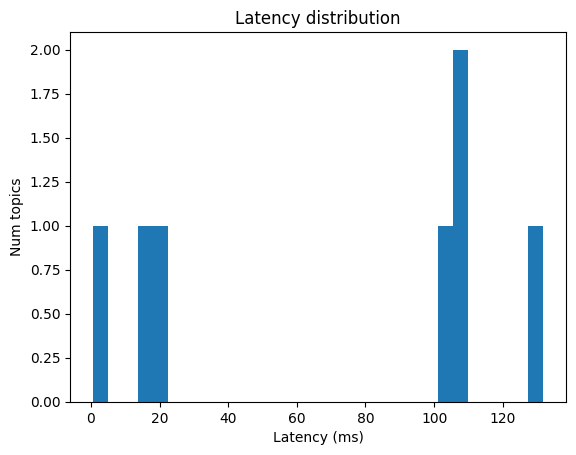

In [22]:
valid = df_dep[df_dep["lat_available"]]
plt.hist(valid["lat_mean_ms"], bins=30)
plt.xlabel("Latency (ms)")
plt.ylabel("Num topics")
plt.title("Latency distribution")
plt.show()

## 5.4. Relación BW vs Latencia

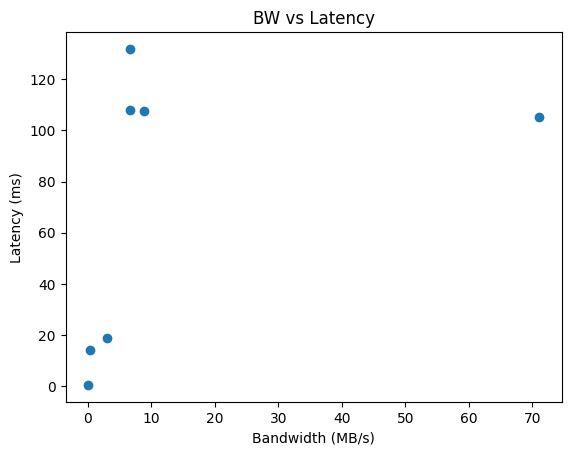

In [23]:
valid = df_dep[df_dep["lat_available"]]
plt.scatter(valid["bw"], valid["lat_mean_ms"])
plt.xlabel("Bandwidth (MB/s)")
plt.ylabel("Latency (ms)")
plt.title("BW vs Latency")
plt.show()

## 5.5. Jitter

In [24]:
df_dep.sort_values(by="jitter_ms", ascending=False)[["topic","jitter_ms"]].head(10)

,topic,jitter_ms
4,/robot/move_base/GlobalPlanner/potential,105.406974
8,/robot/move_base/global_costmap/costmap_updates,81.660682
3,/robot/robot_front_ptz_camera/image_raw,24.367109
1,/robot/front_rgbd_camera/depth/image_raw,23.675922
2,/robot/front_rgbd_camera/rgb/image_raw,23.527657
0,/robot/front_rgbd_camera/depth/points,23.228384
7,/robot/front_laser/scan,15.046288
6,/gazebo/model_states,4.266597
5,/gazebo/link_states,3.714627


## 5.6. Relación Latencia vs Jitter

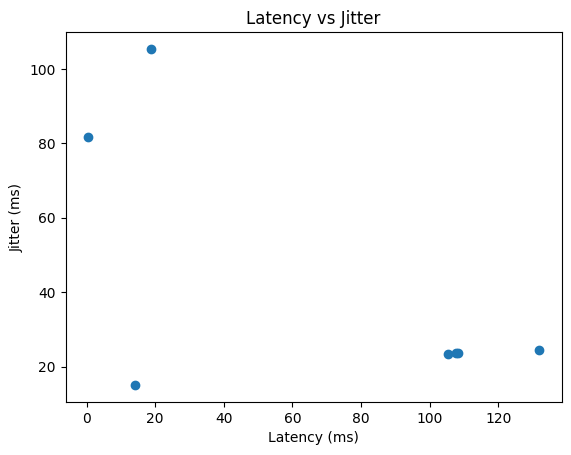

In [25]:
valid = df_dep[df_dep["lat_available"]]
plt.scatter(valid["lat_mean_ms"], valid["jitter_ms"])
plt.xlabel("Latency (ms)")
plt.ylabel("Jitter (ms)")
plt.title("Latency vs Jitter")
plt.show()

## 5.7. Correlaciones

In [26]:
df_dep[["bw","lat_mean_ms","jitter_ms","n_sub","burst_ratio"]].corr()



,bw,lat_mean_ms,jitter_ms,n_sub,burst_ratio
bw,1.000000,0.454072,-0.133163,-0.235165,-0.173966
lat_mean_ms,0.454072,1.000000,-0.217268,-0.373971,-0.242297
jitter_ms,-0.133163,-0.217268,1.000000,-0.030439,-0.123172
n_sub,-0.235165,-0.373971,-0.030439,1.000000,0.928507
burst_ratio,-0.173966,-0.242297,-0.123172,0.928507,1.000000


In [27]:
df_dep[["bw","lat_mean_ms","jitter_ms","n_sub","burst_ratio"]].corr()["lat_mean_ms"]

bw             0.454072
lat_mean_ms    1.000000
jitter_ms     -0.217268
n_sub         -0.373971
burst_ratio   -0.242297
Name: lat_mean_ms, dtype: float64

## 5.8. Outliers

In [28]:

df_dep[df_dep["lat_mean_ms"] > 500][[
    "topic","bw","lat_mean_ms","n_sub"
]]

,topic,bw,lat_mean_ms,n_sub


In [29]:
df_dep[df_dep["burst_ratio"] > 5][[
    "topic","bw","peak_bw","burst_ratio"
]]

,topic,bw,peak_bw,burst_ratio
7,/robot/front_laser/scan,0.331207,8.317947,25.114075


## 5.9. Cuellos de botella

In [ ]:
df_dep[
    (df_dep["lat_mean_ms"] > df_dep["lat_mean_ms"].quantile(0.9)) &
    (df_dep["bw"] > df_dep["bw"].quantile(0.8))
][["topic","bw","lat_mean_ms"]]

## 5.10 Conclusiones

La latencia presenta una distribución heterogénea, con la mayoría de los *topics* en rangos moderados y la presencia de outliers significativos que pueden comprometer el comportamiento del sistema.

No existe una correlación fuerte entre ancho de banda y latencia, lo que indica que los problemas de latencia no dependen únicamente del volumen de datos, sino también de factores como procesamiento, serialización o scheduling.

El jitter muestra variabilidad relevante en ciertos *topics*, lo que puede afectar negativamente a sistemas de control en tiempo real.

El análisis de *burst ratio* evidencia la existencia de tráfico no uniforme en el tiempo, con picos que pueden generar congestión puntual.

En conjunto, el sistema presenta un comportamiento temporal no determinista, con posibles cuellos de botella en *topics* específicos.

# 6. Impacto final

## 6.1. Normalización

In [30]:
max_bw = df_dep["bw"].max()
valid_lat = df_dep[df_dep["lat_available"]]["lat_mean_ms"]
max_lat = valid_lat.max() if not valid_lat.empty else 0

df_dep["bw_norm"] = df_dep["bw"] / max_bw if max_bw > 0 else 0
df_dep["lat_norm"] = df_dep["lat_mean_ms"] / max_lat if max_lat > 0 else 0
df_dep.loc[~df_dep["lat_available"], "lat_norm"] = 0

## 6.2. Clasificación final

In [31]:
df_dep["net_impact"] = df_dep["bw"] * df_dep["n_sub"]
df_dep["fanout_ratio"] = df_dep.apply(
    lambda r: r["n_sub"] / r["n_pub"] if r["n_pub"] > 0 else 0,
    axis=1
)
df_dep["fanout_impact"] = df_dep["bw"] * df_dep["fanout_ratio"]
bw_thr = df_dep["bw"].quantile(0.8)
jitter_thr = df_dep["jitter_ms"].quantile(0.9)
def classify(row):
    if not row["lat_available"]:
        return "unknown"
    elif row["bw"] > bw_thr and row["lat_mean_ms"] > 80:
        return "critical"
    elif row["bw"] > bw_thr:
        return "high_bw"
    elif row["jitter_ms"] > jitter_thr:
        return "unstable"
    else:
        return "low_impact"

df_dep["impact_class"] = df_dep.apply(classify, axis=1)

## 6.3. Ranking final

In [32]:
df_dep.sort_values(
    by=["impact_class","fanout_impact","net_impact"],
    ascending=[True, False, False]
)[[
    "topic","impact_class","fanout_impact","net_impact","bw","lat_mean_ms"
]]

,topic,impact_class,fanout_impact,net_impact,bw,lat_mean_ms
0,/robot/front_rgbd_camera/depth/points,critical,71.088803,71.088803,71.088803,105.280193
1,/robot/front_rgbd_camera/depth/image_raw,critical,8.886586,8.886586,8.886586,107.681159
2,/robot/front_rgbd_camera/rgb/image_raw,low_impact,6.665086,6.665086,6.665086,108.101449
3,/robot/robot_front_ptz_camera/image_raw,low_impact,6.665071,6.665071,6.665071,131.855072
7,/robot/front_laser/scan,low_impact,1.324826,1.324826,0.331207,14.233256
8,/robot/move_base/global_costmap/costmap_updates,low_impact,0.139026,0.139026,0.069513,0.489362
5,/gazebo/link_states,unknown,1.972124,1.972124,1.972124,0.000000
6,/gazebo/model_states,unknown,1.099804,1.099804,1.099804,0.000000
4,/robot/move_base/GlobalPlanner/potential,unstable,3.094075,3.094075,3.094075,18.733333


## 6.4. Descomposición del impacto

In [33]:
df_dep["time_impact"] = df_dep["lat_mean_ms"]
df_dep["network_impact"] = df_dep["net_impact"]
df_dep["stability_impact"] = df_dep["jitter_ms"]

df_dep[[
    "topic","network_impact","time_impact","stability_impact"
]].sort_values(by="network_impact", ascending=False)

,topic,network_impact,time_impact,stability_impact
0,/robot/front_rgbd_camera/depth/points,71.088803,105.280193,23.228384
1,/robot/front_rgbd_camera/depth/image_raw,8.886586,107.681159,23.675922
2,/robot/front_rgbd_camera/rgb/image_raw,6.665086,108.101449,23.527657
3,/robot/robot_front_ptz_camera/image_raw,6.665071,131.855072,24.367109
4,/robot/move_base/GlobalPlanner/potential,3.094075,18.733333,105.406974
5,/gazebo/link_states,1.972124,0.000000,3.714627
7,/robot/front_laser/scan,1.324826,14.233256,15.046288
6,/gazebo/model_states,1.099804,0.000000,4.266597
8,/robot/move_base/global_costmap/costmap_updates,0.139026,0.489362,81.660682


In [36]:
df_dep.sort_values(
    by=["network_impact","time_impact","stability_impact"],
    ascending=[False, False, False]
)

,topic,bw,publishers,subscribers,n_pub,n_sub,pub_type,sub_type,main_type,lat_mean_ms,...,lat_available,bw_norm,lat_norm,net_impact,fanout_ratio,fanout_impact,impact_class,time_impact,network_impact,stability_impact
0,/robot/front_rgbd_camera/depth/points,71.088803,[/gazebo],[/bag_recorder],1,1,[system],[system],system,105.280193,...,True,1.000000,0.798454,71.088803,1.0,71.088803,critical,105.280193,71.088803,23.228384
1,/robot/front_rgbd_camera/depth/image_raw,8.886586,[/gazebo],[/bag_recorder],1,1,[system],[system],system,107.681159,...,True,0.125007,0.816663,8.886586,1.0,8.886586,critical,107.681159,8.886586,23.675922
2,/robot/front_rgbd_camera/rgb/image_raw,6.665086,[/gazebo],[/bag_recorder],1,1,[system],[system],system,108.101449,...,True,0.093757,0.819851,6.665086,1.0,6.665086,low_impact,108.101449,6.665086,23.527657
3,/robot/robot_front_ptz_camera/image_raw,6.665071,[/gazebo],[/bag_recorder],1,1,[system],[system],system,131.855072,...,True,0.093757,1.000000,6.665071,1.0,6.665071,low_impact,131.855072,6.665071,24.367109
4,/robot/move_base/GlobalPlanner/potential,3.094075,[/robot/move_base],[/bag_recorder],1,1,[planning],[system],planning,18.733333,...,True,0.043524,0.142075,3.094075,1.0,3.094075,unstable,18.733333,3.094075,105.406974
5,/gazebo/link_states,1.972124,[/gazebo],[/bag_recorder],1,1,[system],[system],system,0.000000,...,False,0.027742,0.000000,1.972124,1.0,1.972124,unknown,0.000000,1.972124,3.714627
7,/robot/front_laser/scan,0.331207,[/gazebo],"[/bag_recorder, /robot/amcl, /robot/move_base,...",1,4,[system],"[system, localization, planning, system]",system,14.233256,...,True,0.004659,0.107946,1.324826,4.0,1.324826,low_impact,14.233256,1.324826,15.046288
6,/gazebo/model_states,1.099804,[/gazebo],[/bag_recorder],1,1,[system],[system],system,0.000000,...,False,0.015471,0.000000,1.099804,1.0,1.099804,unknown,0.000000,1.099804,4.266597
8,/robot/move_base/global_costmap/costmap_updates,0.069513,[/robot/move_base],"[/bag_recorder, /rviz]",1,2,[planning],"[system, system]",planning,0.489362,...,True,0.000978,0.003711,0.139026,2.0,0.139026,low_impact,0.489362,0.139026,81.660682


## 6.5. Relación fanout vs BW

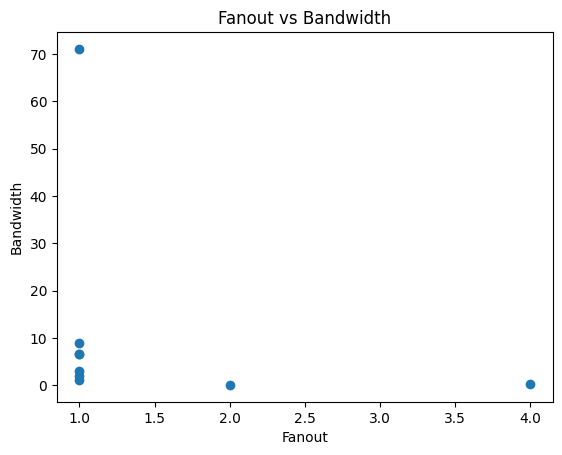

In [34]:
plt.scatter(df_dep["fanout_ratio"], df_dep["bw"])
plt.xlabel("Fanout")
plt.ylabel("Bandwidth")
plt.title("Fanout vs Bandwidth")
plt.show()

## 6.6. Candidatos a offloading

In [37]:
df_dep[
    (df_dep["impact_class"] == "critical") &
    (df_dep["fanout_impact"] > df_dep["fanout_impact"].quantile(0.8))
][[
    "topic","bw","lat_mean_ms","fanout_impact"
]]

,topic,bw,lat_mean_ms,fanout_impact
0,/robot/front_rgbd_camera/depth/points,71.088803,105.280193,71.088803
1,/robot/front_rgbd_camera/depth/image_raw,8.886586,107.681159,8.886586


## 6.7. Conclusiones


El impacto de un *topic* no depende únicamente de su ancho de banda, sino de la combinación de múltiples factores: volumen de datos, latencia y número de suscriptores.

El concepto de *fanout impact* permite identificar *topics* que, aunque no sean los más pesados individualmente, generan una carga significativa al distribuirse a múltiples nodos.

Los *topics* clasificados como críticos combinan alto ancho de banda y alta latencia, representando los principales cuellos de botella del sistema.

Estos resultados permiten identificar candidatos claros para estrategias de optimización, como compresión, reducción de frecuencia o offloading hacia nodos edge.

# 7. Conclusiones globales

El sistema analizado presenta una arquitectura fuertemente dominada por flujos de datos de percepción, donde un número reducido de *topics* concentra la mayor parte del tráfico y del impacto en red.

Se ha demostrado que el ancho de banda está principalmente determinado por el tamaño de los mensajes, mientras que la latencia y el jitter dependen de factores adicionales relacionados con procesamiento y distribución.

El análisis estructural y temporal permite identificar *topics* críticos que actúan como cuellos de botella, especialmente aquellos con alto volumen de datos y elevado fanout.

Estos resultados justifican la necesidad de aplicar estrategias de optimización, particularmente mediante offloading hacia arquitecturas edge, donde el procesamiento cercano a la fuente de datos puede reducir tanto la latencia como la carga de red.

En conjunto, el análisis proporciona una base sólida para el diseño de arquitecturas distribuidas eficientes en sistemas robóticos conectados.